In [1]:
import numpy as np
import pandas as pd
import os
import joblib
import pickle
import math
import ast
from scipy.stats import median_abs_deviation, hypergeom, mannwhitneyu
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
# Saving plots with editable text
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts (editable text)

# Fig 5/6 - Episodic enrichment plots
### Direct effect enrichment 

In [27]:
df_ep1 = pd.read_csv(config.ETS1_ALL['ep1'])
df_ep2 = pd.read_csv(config.ETS1_ALL['ep2'])
df_ep3 = pd.read_csv(config.ETS1_ALL['ep3'])
df_ep4 = pd.read_csv(config.ETS1_ALL['ep4'])
df_ep5 = pd.read_csv(config.ETS1_ALL['ep5'])
df_ep6 = pd.read_csv(config.ETS1_ALL['ep6'])
# df_ep7 = pd.read_csv(config.IKZF1_ALL['ep7'])
# df_ep8 = pd.read_csv(config.IKZF1_ALL['ep8'])

Filtered to 69 TFs that meet gene count criteria
Further filtered to 9 TFs that meet significance threshold < 0.004


/ocean/projects/cis240075p/asachan/bio_informatics_analysis/B_Cells_human_analysis/src/multiome_dynamic_regulation/py_scripts/analysis/episode_plots.py:420: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


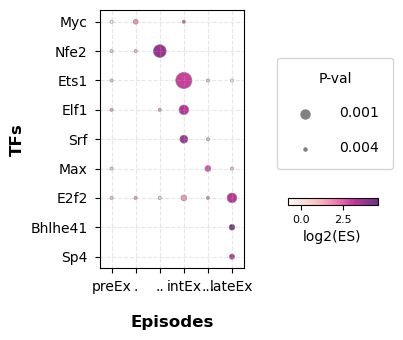

In [31]:
# TF order

#custom_tf_order_prdm1 = ['BPTF', 'SP1', 'BATF3', 'RBPJ', 'IKZF2']
#custom_tf_order_irf4 = ['MBD2', 'IKZF2', 'RBPJ', 'TCF12', 'BACH1', 'HMG20A']
#episode_labels=['ActB1/2', '.', '..', 'ActB3/4', '...', '....', '.....', 'lateGC']

# custom_tf_order_ets1_sig = ['Hdac2', 'Nfkb1', 'Ets1', 'Sin3a', 'Max']
#custom_tf_order_ikzf1_all = ['Ep300', 'E2f2', 'Klf6', 'Nfe2', 'Taf1', 'Nr4a2', 'Bhlhe40', 'Rad21', 'Klf2', 'Ctcf']
custom_tf_order_ets1_all = ['Myc', 'Nfe2', 'Ets1', 'Elf1', 'Srf', 'Max', 'E2f2', 'Bhlhe41', 'Sp4']
episode_labels=['preEx', '.', '..', 'intEx', '...', 'lateEx']

# custom_tf_order_z11_pb = ['CREB3L2', 'MEF2C', 'TFEC', 'TEAD2', 'IRF8', 'IRF9']
# custom_tf_order_z11_gc = ['IKZF3', 'USF2', 'IRF7', 'MEF2C', 'CDC5L', 'POU2F1']

# Use it in the plot
fig, plot_data, plotted_tfs = plot_tf_episodic_enrichment_dotplot(
    dfs=[df_ep1, df_ep2, df_ep3, df_ep4, df_ep5, df_ep6],
    episode_labels=episode_labels,
    figsize=(4.5, 3.5), #breadth by length
    p_value_threshold=0.004,
    min_significance_threshold=0.004,
    min_dot_size=10,    
    max_dot_size=200,   
    cmap_name="RdPu",
    tf_order=custom_tf_order_ets1_all,
    figure_title=None,
    log_scale=True,
    horizontal_layout=False
)
# save the plot
fig.savefig(os.path.join(config.OUTPUT_FOLDER, "ets1_ee.pdf"), dpi=300)

# Ext. Fig 3 - Chromatin level TF activity over pseudotime

In [5]:
# list static and episodic TFs
static_tfs_fig3 = [
    'CREB3L2',
    'PRDM1',
    'IRF4',
    'BATF',
    'PAX5',
]
episodic_tfs_fig3 = [
    'MEF2C',
    'USF2',
    'IRF7',
    'TFEC',
    'TEAD2',
]
pb_lineage_tfs_fig3 = [
    'RUNX2',
    'CREB3L2',
    'PRDM1',
    'IRF4',
    'XBP1',
]
gc_lineage_tfs_fig3 = [
    'BACH2',
    'SPIB',
    'BATF',
    'PAX5',
    'IRF8',
]

static_tfs_fig4 = ['PAX5',
    'BATF',
    'BACH2']
episodic_tfs_fig4 = ['IKZF2',
    'RBPJ',
    'NFATC2']
other_tfs_fig4 = ['NR4A3',
    'MXI1',
    'TRPS1']

all_tfs_fig3 = list(set(static_tfs_fig3 + episodic_tfs_fig3 + pb_lineage_tfs_fig3 + gc_lineage_tfs_fig3))
all_tfs_fig4 = list(set(static_tfs_fig4 + episodic_tfs_fig4 + other_tfs_fig4))
base_path = '/ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/dictys_outs/actb1_added_v2/tmp_dynamic'

In [6]:
smooth_chromatin_object = SmoothedCurvesChromatin(
    tfs=None,
    base_path=base_path
)

In [7]:
# Get pseudotime values for all windows
aligner_pb = AlignTimeScales(
    dictys_dynamic_object=dictys_dynamic_object,
    trajectory_range=(1, 2),  # any trajectory starting from 1
    num_points=40,
    dist=0.001,
    sparsity=0.01
)
aligner_gc = AlignTimeScales(
    dictys_dynamic_object=dictys_dynamic_object,
    trajectory_range=(1, 3),  # any trajectory starting from 1
    num_points=40,
    dist=0.001,
    sparsity=0.01
)
window_pseudotimes = aligner_pb.pseudotime_of_windows()

In [8]:
smooth_chromatin_object.set_trajectory_info(
    pb_indices=[1] + list(range(97, 3, -1)) + [0] + list(range(98, 147, 1)) + [2],
    gc_indices=[1] + list(range(97, 3, -1)) + [0] + list(range(147, 193, 1)) + [3],
    window_pseudotimes=window_pseudotimes
)

In [9]:
smooth_chromatin_object.extract_data(n_windows=194, n_processes=None)

Processing 194 windows using 127 processes...


Extracting Binding Data: 100%|██████████| 194/194 [00:12<00:00, 15.35it/s]


Discovered 551 TFs across all windows.
Extraction complete.


#### choose metric and plot it across pseudotime

In [11]:
smooth_chromatin_object.process_dynamics(metric='score', smooth_sigma=2.0, relative=False)

In [12]:
fig = smooth_chromatin_object.plot(
    categories=categories_fig3,
    y_label="TF Binding Score",
    title=None
)
fig.show()
# save the figure
#fig.write_image(os.path.join(config.OUTPUT_FOLDER, "binding_score_all_tfs_ext_fig_3.svg"), format='svg')

In [13]:
# fig = smooth_chromatin_object.plot_score_vs_count_comparison(
#     categories=categories_fig4,
#     smooth_sigma=2.0,
#     subplot_cols=3,
#     title="OCR Count vs TF Binding Score (GC branch)"
# )
# fig.show()
# # save svg fig
# #fig.write_image(os.path.join(config.OUTPUT_FOLDER, "binding_score_vs_count_comparison_ext_fig_4.svg"), format='svg')

### Binned chromatin dynamics

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from itertools import cycle


# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def softmax_binned_series(binned_series, tfs, temperature=0.01):
    """
    Apply per-bin softmax to a binned TF series.

    Parameters
    ----------
    binned_series : {tf: [bin0_vals, bin1_vals, ...]}
    tfs           : list of TF names to apply softmax to
    temperature   : float, controls sharpness (lower = more peaked)
    """
    return {
        tf: [
            np.exp(vals / temperature) / np.sum(np.exp(vals / temperature))
            for vals in binned_series[tf]
        ]
        for tf in tfs
    }


def _get_series(chromatin_object, lineage, metric):
    """
    Extract the correct series dict and pseudotime array from a chromatin object.

    Parameters
    ----------
    lineage : 'pb' | 'gc'
    metric  : 'score' | 'count'
    """
    if lineage == 'pb':
        pseudotime = chromatin_object.pb_pseudotime
        series = chromatin_object.series_pb
    elif lineage == 'gc':
        pseudotime = chromatin_object.gc_pseudotime
        series = chromatin_object.series_gc
    else:
        raise ValueError(f"lineage must be 'pb' or 'gc', got '{lineage}'")
    return pseudotime, series


# ---------------------------------------------------------------------------
# Core binning
# ---------------------------------------------------------------------------

def make_bins(
    chromatin_object,
    aligner,
    bin_partition_indices,      # indices into episode partition array, e.g. [2, 3, 7]
    lineage,                    # 'pb' | 'gc'
    metric='score',             # 'score' | 'count' — for y-axis labelling only, data already in object
    tfs=None,                   # subset of TFs to bin; None = all TFs in object
    points_per_episode=5,
    softmax=False,
    softmax_temperature=0.01,
):
    """
    Bin a chromatin object's TF series along one lineage.

    Parameters
    ----------
    chromatin_object       : SmoothedCurvesChromatin or CountChromatin (any object
                             with pb_pseudotime/gc_pseudotime and series_pb/series_gc)
    aligner                : AlignTimeScales for this lineage
    bin_partition_indices  : list[int], indices into episode partition pseudotimes
                             defining bin boundaries. Last index = filter cutoff.
    lineage                : 'pb' | 'gc'
    metric                 : 'score' | 'count', stored in result for downstream use
    tfs                    : list[str] | None, TFs to include (default: all in object)
    points_per_episode     : int, spacing of episode partitions in sampled points
    softmax                : bool
    softmax_temperature    : float

    Returns
    -------
    dict:
        binned_series      : {tf: [bin0_vals, bin1_vals, ...]}
        bin_labels         : np.array of bin indices per window
        filtered_pseudotime: pseudotime values within cutoff
        filtered_series    : {tf: values} filtered to cutoff
        n_bins             : int
        lineage            : 'pb' | 'gc'
        metric             : 'score' | 'count'
    """
    # equispaced pseudotime points → episode partition array
    pts = aligner.pseudotime_of_sampled_points()
    ep_partitions = pts[points_per_episode - 1::points_per_episode]

    # cutpoints and filter bound
    cutpoints = ep_partitions[bin_partition_indices]
    last_pt   = cutpoints[-1]

    # extract pseudotime + series for this lineage
    pseudotime, series = _get_series(chromatin_object, lineage, metric)

    # optionally restrict to a TF subset
    if tfs is not None:
        series = {tf: series[tf] for tf in tfs if tf in series}

    # filter windows to [0, last_pt]
    mask = pseudotime <= last_pt
    filtered_pseudotime = pseudotime[mask]
    filtered_series     = {tf: v[mask] for tf, v in series.items()}

    # digitize
    n_bins     = len(bin_partition_indices)
    bin_labels = np.digitize(filtered_pseudotime, cutpoints)

    # bin TF series
    binned_series = {
        tf: [vals[bin_labels == b] for b in range(n_bins)]
        for tf, vals in filtered_series.items()
    }

    # optional softmax
    if softmax:
        binned_series = softmax_binned_series(binned_series, list(binned_series.keys()), softmax_temperature)

    # sanity check
    tf_ex = next(iter(binned_series))
    print(f"[{lineage.upper()} | {metric}] Bin sizes for '{tf_ex}':")
    for b, arr in enumerate(binned_series[tf_ex]):
        print(f"  Bin {b}: {len(arr)} windows")

    return dict(
        binned_series=binned_series,
        bin_labels=bin_labels,
        filtered_pseudotime=filtered_pseudotime,
        filtered_series=filtered_series,
        n_bins=n_bins,
        lineage=lineage,
        metric=metric,
    )


In [37]:
def plot_single_lineage_tf_category_bins(
    result,
    tf_categories,
    title,
    show_other=True,
    fill_opacity=0.5,
    skip_when_not_other=('PB Lineage', 'GC Lineage'),
):
    """
    Plotly boxplot of mean TF values per bin, grouped by category.
    Each dot = one TF's mean value in that bin.

    Parameters
    ----------
    result               : dict returned by make_bins (single lineage)
    tf_categories        : dict {category_name: {tf: hex_color} | list[str]}
    title                : str
    show_other           : if False, skip categories listed in
                           `skip_when_not_other`. All other categories
                           (Static, Episodic, Random, ...) are shown.
    skip_when_not_other  : tuple of category names to drop when show_other=False.
                           Defaults to the lineage categories from fig3.
    """
    binned_series = result['binned_series']
    n_bins        = result['n_bins']
    metric        = result['metric']
    y_label       = {'score': 'Mean TF Binding Score', 'count': 'Mean TF Count'}.get(metric, metric)

    fallback_palette = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a', '#f4a261', '#9b2335']
    bin_labels = [f'Bin {b}' for b in range(n_bins)]
    fig = go.Figure()

    def hex_to_rgba(hex_color, alpha):
        h = hex_color.lstrip('#')
        r, g, b = tuple(int(h[i:i+2], 16) for i in (0, 2, 4))
        return f'rgba({r},{g},{b},{alpha})'

    for (cat, tfs_entry), fallback_color in zip(tf_categories.items(), cycle(fallback_palette)):
        # NEW: explicit skip-list rather than implicit allow-list
        if not show_other and cat in skip_when_not_other:
            continue

        if isinstance(tfs_entry, dict):
            tfs       = list(tfs_entry.keys())
            cat_color = next(iter(tfs_entry.values()))
        else:
            tfs       = tfs_entry
            cat_color = fallback_color

        fill_rgba = hex_to_rgba(cat_color, fill_opacity)

        # mean per TF per bin → (n_tfs, n_bins)
        means = np.array([
            [np.mean(binned_series[tf][b]) if tf in binned_series and len(binned_series[tf][b]) > 0 else np.nan
             for b in range(n_bins)]
            for tf in tfs
        ])

        for b in range(n_bins):
            fig.add_trace(go.Box(
                x=[bin_labels[b]] * len(tfs),
                y=means[:, b],
                name=cat,
                legendgroup=cat,
                showlegend=(b == 0),
                marker=dict(color=cat_color, size=10, opacity=0.9),
                line=dict(color=cat_color),
                fillcolor=fill_rgba,
                boxpoints='all',
                pointpos=0,
                jitter=0.3,
                text=tfs,
                hovertemplate='<b>%{text}</b><br>Mean: %{y:.4f}<extra></extra>',
            ))

    fig.update_layout(
        title=title,
        xaxis_title='Bin',
        yaxis_title=y_label,
        boxmode='group',
        template='plotly_white',
        legend=dict(groupclick='toggleitem'),
        height=500,
        width=900,
    )
    return fig

In [19]:
# --- bin score (smooth chromatin) ---
result_pb = make_bins(
    chromatin_object=smooth_chromatin_object,
    aligner=aligner_pb,
    bin_partition_indices=[2, 3, 7],
    lineage='pb',
    metric='score',
    tfs=None,
    softmax=False,
    softmax_temperature=0.01,
)
result_gc = make_bins(
    chromatin_object=smooth_chromatin_object,
    aligner=aligner_gc,
    bin_partition_indices=[2, 4, 7],
    lineage='gc',
    metric='score',
    tfs=None,
    softmax=False,
    softmax_temperature=0.01,
)

[PB | score] Bin sizes for 'AHR':
  Bin 0: 102 windows
  Bin 1: 25 windows
  Bin 2: 18 windows
[GC | score] Bin sizes for 'AHR':
  Bin 0: 92 windows
  Bin 1: 9 windows
  Bin 2: 40 windows


In [73]:
import numpy as np

keys = list(result_pb['binned_series'].keys())
binned = result_pb['binned_series']

In [74]:
idx = np.random.default_rng(seed=50).choice(len(keys), size=5, replace=False)
randomly_chosen_tfs = [keys[i] for i in idx]

In [75]:
display(randomly_chosen_tfs)

['ZNF557', 'ZNF433', 'ZNF540', 'ZNF425', 'ZNF283']

#### controlled - random (selecting for non-0 tf binding)

In [76]:
viable = [tf for tf, arr in binned.items() if not np.isnan(arr[0]).all()]
idx = np.random.default_rng(seed=50).choice(len(viable), size=5, replace=False)
controlled_randomly_chosen_tfs = [viable[i] for i in idx]

In [77]:
display(controlled_randomly_chosen_tfs)

['ZNF485', 'ZNF37A', 'ZNF460', 'ZNF345', 'ZNF232']

### our prioritized sub-list

In [78]:
categories_fig3 = {
    "Static": {
        "CREB3L2": "#3F007D",  # Purple-5 (darkest)
        "PRDM1":   "#6A51A3",  # Purple-4
        "IRF4":    "#9E9AC8",  # Purple-3
        "BATF":    "#CBC9E2",  # Purple-2
        "PAX5":    "#F2F0F7",  # Purple-1 (lightest)
    },
    "Episodic": {
        "MEF2C":  "#7F2704",   # Orange-5 (darkest)
        "USF2":   "#D94801",   # Orange-4
        "IRF7":   "#F16913",   # Orange-3
        "TFEC":   "#FD8D3C",   # Orange-2
        "TEAD2":  "#FEE6CE",   # Orange-1 (lightest)
    },
    "PB Lineage": {
        "RUNX2":   "#67000D",  # Red-5 (darkest)
        "CREB3L2": "#A50F15",  # Red-4
        "PRDM1":   "#EF3B2C",  # Red-3
        "IRF4":    "#FC9272",  # Red-2
        "XBP1":    "#FEE0D2",  # Red-1 (lightest)
    },
    "GC Lineage": {
        "BACH2":   "#00441B",  # Green-5 (darkest)
        "SPIB":    "#238B45",  # Green-4
        "BATF":    "#41AB5D",  # Green-3
        "PAX5":    "#A1D99B",  # Green-2
        "IRF8":    "#E5F5E0",  # Green-1 (lightest)
    },
}

categories_fig4 = {
    "Static": {
        "PAX5":    "#DADAEB",  # Lighter purple
        "BATF":    "#BCBDDC",  # Light purple
        "BACH2":   "#9E9AC8",  # Medium purple
    },
    "Episodic": {
        "IKZF2":   "#D94701",   # Dark orange
        "RBPJ":    "#F16913",   # Orange
        "NFATC2":  "#FD8D3C",   # Medium orange
    },
    "Other": {
        "NR4A3": "#08519C",  # Dark blue
        "MXI1": "#3182BD",  # Medium blue
        "TRPS1": "#9ECAE1"  # Light blue
    }
}

In [79]:
# ColorBrewer Greys 5-class, dark→light to match the existing pattern
grey_palette = ["#252525", "#636363", "#969696", "#CCCCCC", "#F0F0F0"]

random_category = {
    "Random": {tf: grey_palette[i] for i, tf in enumerate(randomly_chosen_tfs)}
}
controlled_random_category = {
    "Controlled Random": {tf: grey_palette[i] for i, tf in enumerate(controlled_randomly_chosen_tfs)}
}
categories_fig3_with_random = {**categories_fig3, **random_category}
categories_fig3_with_controlled_random = {**categories_fig3, **controlled_random_category}

In [80]:
fig = plot_single_lineage_tf_category_bins(
    result=result_pb,
    tf_categories=categories_fig3_with_controlled_random,
    title='PB Branch - Size Matched picking of TFs with > 0 binding score',
    show_other=False,
    fill_opacity=0.3,
)
fig.show()
fig.write_image(os.path.join(config.OUTPUT_FOLDER, "updated_binding_controlled_random_pb.svg"), format='svg')


In [72]:
fig = plot_single_lineage_tf_category_bins(
    result=result_gc,
    tf_categories=categories_fig3_with_controlled_random,
    title='GC Branch - Size Matched picking of TFs with > 0 binding score',
    show_other=False,
    fill_opacity=0.3,
)
fig.show()
fig.write_image(os.path.join(config.OUTPUT_FOLDER, "updated_binding_controlled_random_gc.svg"), format='svg')


In [17]:
def plot_both_lineages_tf_category_bins(
    result_pb,
    result_gc,
    tf_categories,
    fill_opacity=0.5,
):
    """
    Single Plotly figure with PB Lineage and GC Lineage TFs side-by-side per bin.
    PB Lineage TFs are drawn from result_pb; GC Lineage TFs from result_gc.

    Parameters
    ----------
    result_pb / result_gc : dicts returned by make_bins
    tf_categories         : dict containing at minimum 'PB Lineage' and 'GC Lineage' keys,
                            each mapping {tf: hex_color}
    fill_opacity          : float

    Returns
    -------
    fig : plotly.graph_objects.Figure
    """
    assert result_pb['n_bins'] == result_gc['n_bins'], "PB and GC results must have the same n_bins"

    n_bins    = result_pb['n_bins']
    metric    = result_pb['metric']
    y_label   = {'score': 'Mean TF Binding Score', 'count': 'Mean TF Count'}.get(metric, metric)
    bin_labels = [f'Bin {b}' for b in range(n_bins)]

    def hex_to_rgba(h, a):
        h = h.lstrip('#')
        r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
        return f'rgba({r},{g},{b},{a})'

    cfg = {
        'PB Lineage': (result_pb, tf_categories['PB Lineage']),
        'GC Lineage': (result_gc, tf_categories['GC Lineage']),
    }

    fig = go.Figure()

    for cat, (res, tfs_entry) in cfg.items():
        bs      = res['binned_series']
        tf_list = [tf for tf in tfs_entry if tf in bs]
        cat_color = next(iter(tfs_entry.values()))
        fill_rgba = hex_to_rgba(cat_color, fill_opacity)

        means = np.array([
            [np.mean(bs[tf][b]) if len(bs[tf][b]) > 0 else np.nan for b in range(n_bins)]
            for tf in tf_list
        ])

        for b in range(n_bins):
            fig.add_trace(go.Box(
                x=[bin_labels[b]] * len(tf_list),
                y=means[:, b],
                name=cat,
                legendgroup=cat,
                showlegend=(b == 0),
                marker=dict(color=cat_color, size=10, opacity=0.9),
                line=dict(color=cat_color),
                fillcolor=fill_rgba,
                boxpoints='all',
                pointpos=0,
                jitter=0.3,
                text=tf_list,
                hovertemplate='<b>%{text}</b><br>Mean: %{y:.4f}<extra></extra>',
            ))

    fig.update_layout(
        title='TF Binding Score by Bin — PB & GC Lineage',
        xaxis_title='Bin',
        yaxis_title=y_label,
        boxmode='group',
        template='plotly_white',
        legend=dict(groupclick='toggleitem'),
        height=500,
        width=900,
    )
    return fig

In [18]:
fig3 = plot_both_lineages_tf_category_bins(result_pb, result_gc, categories_fig3)
fig3.show()